In [ ]:
pip install peft

In [10]:
# ================================================
# Chest X-ray Pneumonia Classification
# Notebook 4: LoRA (Low-Rank Adaptation) Fine-tuning
# ================================================

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import timm
from peft import LoraConfig, get_peft_model  # LoRA tools

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [12]:
# ================================================
# Paths and DataLoaders
# ================================================

DATA_DIR  = r"C:\Users\maria\Documents\chest_xray_project\data\chest_xray"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

BATCH_SIZE   = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("Data ready!")

Train: 5216 | Val: 16 | Test: 624
Data ready!


In [13]:
# ================================================
# Load base ViT model (same architecture as before)
# ================================================

base_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=2
)

# First, let's see the layer names so we know what to target with LoRA
print("Looking at model structure to find attention layers...")
for name, module in base_model.named_modules():
    if "qkv" in name or "proj" in name:
        print(name)

Looking at model structure to find attention layers...
patch_embed.proj
blocks.0.attn.qkv
blocks.0.attn.proj
blocks.0.attn.proj_drop
blocks.1.attn.qkv
blocks.1.attn.proj
blocks.1.attn.proj_drop
blocks.2.attn.qkv
blocks.2.attn.proj
blocks.2.attn.proj_drop
blocks.3.attn.qkv
blocks.3.attn.proj
blocks.3.attn.proj_drop
blocks.4.attn.qkv
blocks.4.attn.proj
blocks.4.attn.proj_drop
blocks.5.attn.qkv
blocks.5.attn.proj
blocks.5.attn.proj_drop
blocks.6.attn.qkv
blocks.6.attn.proj
blocks.6.attn.proj_drop
blocks.7.attn.qkv
blocks.7.attn.proj
blocks.7.attn.proj_drop
blocks.8.attn.qkv
blocks.8.attn.proj
blocks.8.attn.proj_drop
blocks.9.attn.qkv
blocks.9.attn.proj
blocks.9.attn.proj_drop
blocks.10.attn.qkv
blocks.10.attn.proj
blocks.10.attn.proj_drop
blocks.11.attn.qkv
blocks.11.attn.proj
blocks.11.attn.proj_drop


In [15]:
# ================================================
# Configure LoRA
# ================================================

lora_config = LoraConfig(
    r=8,                          # rank - size of adapter matrices (small = fewer params)
    lora_alpha=16,                # scaling factor for LoRA updates
    target_modules=["qkv"],       # apply LoRA to attention query/key/value layers
    lora_dropout=0.1,             # dropout for regularization
    bias="none",
    modules_to_save=["head"],     # also train the final classification head normally
)

# Wrap the base model with LoRA
model_lora = get_peft_model(base_model, lora_config)
model_lora = model_lora.to(device)

# Print trainable parameters
model_lora.print_trainable_parameters()

trainable params: 296,450 || all params: 86,096,644 || trainable%: 0.3443


c:\Users\maria\Documents\chest_xray_project\venv\Lib\site-packages\peft\mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
c:\Users\maria\Documents\chest_xray_project\venv\Lib\site-packages\peft\tuners\tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [16]:
# ================================================
# Train LoRA Model
# ================================================

NUM_EPOCHS = 5
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(
    filter(lambda p: p.requires_grad, model_lora.parameters()),
    lr=0.001
)

train_losses_lora = []
val_losses_lora   = []
train_accs_lora   = []
val_accs_lora     = []

print("Training LoRA ViT...")
print("-" * 70)

for epoch in range(NUM_EPOCHS):

    # Training phase
    model_lora.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_lora(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total
    train_losses_lora.append(train_loss)
    train_accs_lora.append(train_acc)

    # Validation phase
    model_lora.eval()
    val_loss = 0.0
    correct  = 0
    total    = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model_lora(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item()
            _, predicted = torch.max(outputs, 1)
            total       += labels.size(0)
            correct     += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc  = 100 * correct / total
    val_losses_lora.append(val_loss)
    val_accs_lora.append(val_acc)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nLoRA Training Complete!")

Training LoRA ViT...
----------------------------------------------------------------------
Epoch [1/5] Train Loss: 0.1390 | Train Acc: 94.10% | Val Loss: 0.4160 | Val Acc: 75.00%
Epoch [2/5] Train Loss: 0.0724 | Train Acc: 97.60% | Val Loss: 0.3391 | Val Acc: 75.00%
Epoch [3/5] Train Loss: 0.0714 | Train Acc: 97.32% | Val Loss: 0.0927 | Val Acc: 93.75%
Epoch [4/5] Train Loss: 0.0748 | Train Acc: 97.30% | Val Loss: 0.5839 | Val Acc: 68.75%
Epoch [5/5] Train Loss: 0.0552 | Train Acc: 97.99% | Val Loss: 0.1163 | Val Acc: 93.75%

LoRA Training Complete!


LoRA ViT - Test Set Results
              precision    recall  f1-score   support

      NORMAL       0.98      0.74      0.84       234
   PNEUMONIA       0.86      0.99      0.92       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.88       624
weighted avg       0.91      0.90      0.89       624



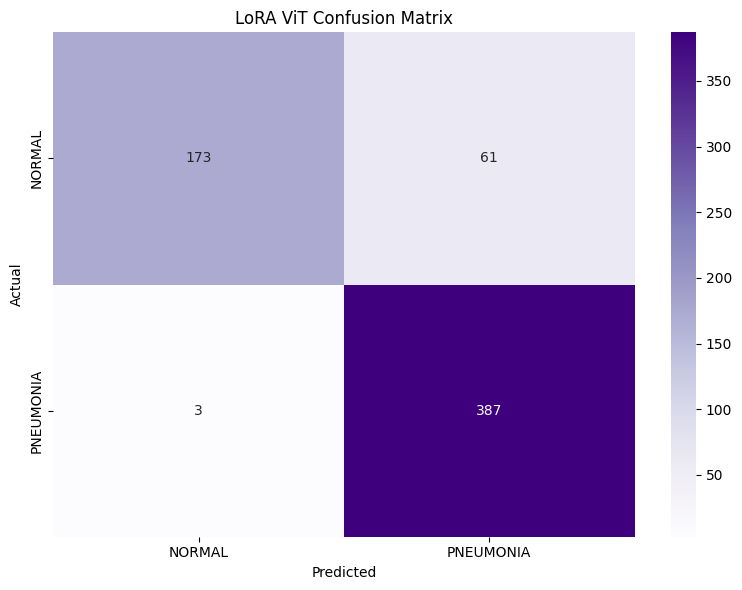

In [17]:
# ================================================
# Evaluate LoRA on Test Set
# ================================================

model_lora.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model_lora(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("=" * 50)
print("LoRA ViT - Test Set Results")
print("=" * 50)
print(classification_report(all_labels, all_preds,
      target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.title("LoRA ViT Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

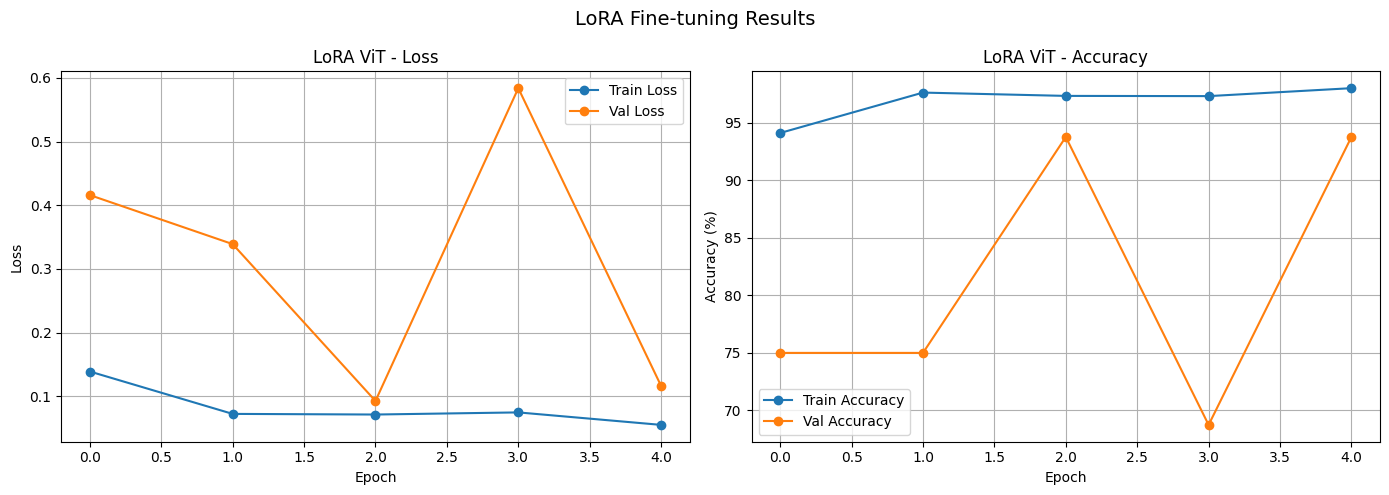

In [18]:
# ================================================
# Plot LoRA Training Curves
# ================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_lora, label="Train Loss", marker="o")
ax1.plot(val_losses_lora,   label="Val Loss",   marker="o")
ax1.set_title("LoRA ViT - Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs_lora, label="Train Accuracy", marker="o")
ax2.plot(val_accs_lora,   label="Val Accuracy",   marker="o")
ax2.set_title("LoRA ViT - Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.suptitle("LoRA Fine-tuning Results", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# ================================================
# Save LoRA Model
# ================================================

import os
os.makedirs("../outputs", exist_ok=True)

model_lora.save_pretrained("../outputs/vit_lora")
print("LoRA model saved!")

LoRA model saved!
